<a href="https://colab.research.google.com/github/sari-saba-sadiya/Unravelling-Brain-Func-LAION/blob/main/Ruxandra/Taskonomy_NSD_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taskonomy–NSD Variance Partitioning Pipeline

This notebook implements the complete analysis pipeline for comparing
task-specific Taskonomy representations with neural representational
dissimilarity matrices (RDMs) from the NSD shared-stimulus dataset.

The pipeline includes:
- loading the NSD shared dataset
- extracting representations from Taskonomy models
- computing model RDMs
- grouping models into 2D, 3D, and Semantic task clusters
- loading NSD brain RDMs
- variance partitioning across cortical ROIs
- aggregation across subjects
- visualization of unique and shared explained variance

Data files and extracted features are not included in this repository.

In [ ]:
# Install required packages

!pip install -q tokenizers
!pip install -q --no-deps git+https://github.com/cvai-roig-lab/Net2Brain.git
!pip install -q torchextractor
!pip install -q git+https://github.com/CSAILVision/semantic-segmentation-pytorch.git@master

In [ ]:
# Imports

import os
import gc
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scipy.spatial.distance import pdist
from sklearn.linear_model import LinearRegression

from net2brain.feature_extraction import FeatureExtractor

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

## 2. NSD Shared Dataset

The analysis uses the 872 shared NSD stimuli provided through Net2Brain.
The dataset is downloaded automatically and is not included in this repository.

In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount("/content/drive")

# Main directories

BASE_DIR = "/content/drive/MyDrive/Taskonomy_NSD"

DATA_DIR = os.path.join(
    BASE_DIR,
    "Algonauts23_shared_Net2Brain"
)

IMAGES_DIR = os.path.join(
    DATA_DIR,
    "images"
)

RDM_DIR = os.path.join(
    BASE_DIR,
    "RDMs"
)

RESULTS_DIR = os.path.join(
    BASE_DIR,
    "results"
)

os.makedirs(RDM_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)

In [ ]:
from net2brain.utils.download_datasets import DatasetNSD_872

print("Import successful!")

Import successful!


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/Taskonomy_NSD"
os.makedirs(project_path, exist_ok=True)

print("Project folder:", project_path)
print("Exists:", os.path.exists(project_path))

Project folder: /content/drive/MyDrive/Taskonomy_NSD
Exists: True


In [ ]:
from net2brain.utils.download_datasets import DatasetNSD_872

NSD_dataset = DatasetNSD_872()

paths = NSD_dataset.load_dataset(
    path="/content/drive/MyDrive/Taskonomy_NSD/NSD_872"
)

print(paths)

ConnectionError: HTTPSConnectionPool(host='hessenbox-a10.rz.uni-frankfurt.de', port=443): Max retries exceeded with url: /dl/fiSExLpb1b84jTi4QYXH2n/NSD%20Dataset.zip (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7e429afee120>: Failed to resolve 'hessenbox-a10.rz.uni-frankfurt.de' ([Errno -2] Name or service not known)"))

In [ ]:
import requests

url = "https://hessenbox-a10.rz.uni-frankfurt.de"

try:
    r = requests.get(url, timeout=10)
    print("Status:", r.status_code)
except Exception as e:
    print("Connection failed:")
    print(e)

Connection failed:
HTTPSConnectionPool(host='hessenbox-a10.rz.uni-frankfurt.de', port=443): Max retries exceeded with url: / (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7e429b091bd0>: Failed to resolve 'hessenbox-a10.rz.uni-frankfurt.de' ([Errno -2] Name or service not known)"))


In [ ]:
!pip install -U --force-reinstall --no-deps git+https://github.com/cvai-roig-lab/Net2Brain.git

  Cloning https://github.com/cvai-roig-lab/Net2Brain.git to /tmp/pip-req-build-nkkxb74q
  Running command git clone --filter=blob:none --quiet https://github.com/cvai-roig-lab/Net2Brain.git /tmp/pip-req-build-nkkxb74q
  Resolved https://github.com/cvai-roig-lab/Net2Brain.git to commit 99374b325f3e25902e5ffdbfb965fa04706550af
  Preparing metadata (setup.py) ... done
  Created wheel for net2brain: filename=net2brain-1.3.3-py3-none-any.whl size=170187 sha256=5e6feb9d871dfd6cdfd6b9ca3dc8a686115d0cbe80b090fad1bc0589beb0b70f
  Stored in directory: /tmp/pip-ephem-wheel-cache-cqj6ykqn/wheels/14/6d/29/1b622e12a31bfbd381b78e604507a0980f44198c83b6a7fcd0
Successfully built net2brain
  Attempting uninstall: net2brain
    Found existing installation: net2brain 1.1.2
    Uninstalling net2brain-1.1.2:
      Successfully uninstalled net2brain-1.1.2


In [ ]:
import net2brain

print("Net2Brain version:", net2brain.__version__)

AttributeError: module 'net2brain' has no attribute '__version__'

In [ ]:
from net2brain.utils.download_datasets import DatasetNSD_872

print("DatasetNSD_872 available!")

ImportError: cannot import name 'DatasetNSD_872' from 'net2brain.utils.download_datasets' (/usr/local/lib/python3.13/dist-packages/net2brain/utils/download_datasets.py)

In [ ]:
import net2brain.utils.download_datasets as dd

print([name for name in dir(dd) if "NSD" in name.upper() or "ALGONAUT" in name.upper()])

['DatasetAlgonauts_NSD', 'DatasetAlgonauts_NSD_Shared']


In [ ]:
from net2brain.utils.download_datasets import DatasetAlgonauts_NSD_Shared
import inspect

print(inspect.signature(DatasetAlgonauts_NSD_Shared))
print(inspect.signature(DatasetAlgonauts_NSD_Shared.load_dataset))

(path=None)
(path=None, save_dir=None)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from net2brain.utils.download_datasets import DatasetAlgonauts_NSD_Shared

nsd_shared = DatasetAlgonauts_NSD_Shared()

paths = nsd_shared.load_dataset(
    save_dir="/content/drive/MyDrive/Taskonomy_NSD"
)

print(paths)

Algonauts23_shared_Net2Brain.zip: 100%|██████████| 2.96G/2.96G [01:39<00:00, 32.1MB/s]


Extracting archive...
Unwrapped nested folder: Algonauts23_shared_Net2Brain
Successfully extracted
{'root': '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain', 'images': '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/images', 'metadata': '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/metadata_shared.csv', 'coco_csv': '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/coco.csv', 'coco_images': '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/coco_images', 'coco_masks': '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/coco_masks', 'subj01': '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/subj01', 'subj01_fmri': '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/subj01/fmri', 'subj01_rois': '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/subj01/rois', 'subj01_rdms': '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Br

In [ ]:
import os

images_path = paths["images"]

images = [
    f for f in os.listdir(images_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Images path:", images_path)
print("Number of images:", len(images))
print("First 5 images:", images[:5])

print("\nAll dataset paths:")
for key, value in paths.items():
    print(key, "->", value)

Images path: /content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/images
Number of images: 872
First 5 images: ['train-3925_nsd-29568.png', 'train-8355_nsd-61873.png', 'train-8447_nsd-62544.png', 'train-6137_nsd-45595.png', 'train-4901_nsd-36569.png']

All dataset paths:
root -> /content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain
images -> /content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/images
metadata -> /content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/metadata_shared.csv
coco_csv -> /content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/coco.csv
coco_images -> /content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/coco_images
coco_masks -> /content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/coco_masks
subj01 -> /content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/subj01
subj01_fmri -> /content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/subj01/fmri
subj01_rois -

In [ ]:
import os

rdm_path = paths["subj01_rdms"]

print("Subject 1 RDM folder:")
print(rdm_path)

print("\nFiles:")
for f in os.listdir(rdm_path):
    print(f)

Subject 1 RDM folder:
/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/subj01/rdms

Files:
VWFA-2_lh_subj01.npy
OWFA_rh_subj01.npy
V2d_lh_subj01.npy
V3v_lh_subj01.npy
OFA_rh_subj01.npy
EBA_lh_subj01.npy
RSC_rh_subj01.npy
V2v_lh_subj01.npy
OPA_lh_subj01.npy
V3d_lh_subj01.npy
VWFA-1_lh_subj01.npy
V1d_lh_subj01.npy
FFA-2_rh_subj01.npy
mfs-words_lh_subj01.npy
FBA-1_rh_subj01.npy
FFA-1_rh_subj01.npy
hV4_lh_subj01.npy
V1v_lh_subj01.npy
FBA-2_rh_subj01.npy
PPA_rh_subj01.npy
VWFA-1_rh_subj01.npy
V3d_rh_subj01.npy
RSC_lh_subj01.npy
V2v_rh_subj01.npy
OPA_rh_subj01.npy
V3v_rh_subj01.npy
EBA_rh_subj01.npy
OFA_lh_subj01.npy
VWFA-2_rh_subj01.npy
OWFA_lh_subj01.npy
V2d_rh_subj01.npy
PPA_lh_subj01.npy
FFA-1_lh_subj01.npy
V1v_rh_subj01.npy
hV4_rh_subj01.npy
FBA-1_lh_subj01.npy
V1d_rh_subj01.npy


In [ ]:
import numpy as np
import os

test_file = os.path.join(rdm_path, "V1v_lh_subj01.npy")

brain_rdm = np.load(test_file)

print("File:", test_file)
print("Shape:", brain_rdm.shape)
print("Data type:", brain_rdm.dtype)
print("First 5 values:", brain_rdm.flatten()[:5])

File: /content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/subj01/rdms/V1v_lh_subj01.npy
Shape: (379756,)
Data type: float64
First 5 values: [1.17185678 0.88549897 1.08115182 0.74772653 0.84048791]


In [ ]:
import pandas as pd

metadata_path = paths["metadata"]

metadata = pd.read_csv(metadata_path)

print("Shape:", metadata.shape)
print("Columns:", metadata.columns.tolist())

display(metadata.head(10))

Shape: (872, 17)
Columns: ['nsd_id', 'coco_id', 'coco_split', 'shared1000', 'subj01', 'subj02', 'subj03', 'subj04', 'subj05', 'subj06', 'subj07', 'subj08', 'caption_1', 'caption_2', 'caption_3', 'caption_4', 'caption_5']


,nsd_id,coco_id,coco_split,shared1000,subj01,subj02,subj03,subj04,subj05,subj06,subj07,subj08,caption_1,caption_2,caption_3,caption_4,caption_5
0,2950,262145,train2017,True,True,True,True,True,True,True,True,True,People shopping in an open market for vegetables.,An open market full of people and piles of veg...,People are shopping at an open air produce mar...,Large piles of carrots and potatoes at a crowd...,People shop for vegetables like carrots and po...
1,2990,262239,train2017,True,True,True,True,True,True,True,True,True,a couple of people are cooking in a room,Two people in chef's outfits cooking inside a ...,two chefs working on seperate parts of a meal ...,a couple of chefs standing in front of some food,A couple of cooks standing in a kitchen making...
2,3049,262414,train2017,True,True,True,True,True,True,True,True,True,A person in a wetsuit surfing on a turquoise w...,A male surfer riding a wave on the ocean.,A young man with a surfboard at the ocean wate...,A surfer is riding the top of a wave.,a person standing on a surfboard riding a wave
3,3077,524646,train2017,True,True,True,True,True,True,True,True,True,a windsurfer some water a hill sand and some k...,A windsurfer coming into a beach where kayaks ...,there is a man wind surfing in a lake,A man is holding a small sail near the canoes.,A man riding a sail board on a large lake.
4,3146,262690,train2017,True,True,True,True,True,True,True,True,True,A brick building with a clock on it and pathway.,a church with a cemetery very close to the bui...,A large church with a tall brick clock tower i...,a very old abandon church with a grave yard,An old white and rust color building with a cl...
5,3157,584,train2017,True,True,True,True,True,True,True,True,True,a plate of yummy food of some kind,Food on a white plate with vegetables and a ga...,A cooked stir fry dish arranged on a plate.,A picture of a bowl of food that is mostly veg...,A close up picture of a meal on a white plate.
6,3164,605,train2017,True,True,True,True,True,True,True,True,True,A cup of coffee on a plate with a spoon.,A cappuccino cup next to plates of deserts.,Cup of coffee with dessert items on a wooden g...,A cup of liquid with a fancy design on top of it.,"Pastry, water and a cup of coffee with spoon."
7,3171,625,train2017,True,True,True,True,True,True,True,True,True,Three young women are trying to catch a frisbee.,A group of woman standing in a field trying to...,Three girls playing frisbee together in a field.,3 people attempt to catch a frisbee in midair.,three people in a grass field reaching for a f...
8,3181,650,train2017,True,True,True,True,True,True,True,True,True,a cat is sitting on top of a vehicle,A cat sitting on top of a car near bushes.,a black gray and white cat a car and bushes,Cat sitting on top of car with brush behind.,A curious looking cat sitting on a car.
9,3386,1308,train2017,True,True,True,True,True,True,True,True,True,A man in swim shorts is riding a surf board.,A surfer is riding a wave in the ocean.,A fit young man surfing a wave in the ocean.,A man riding a surfboard on a wave.,A shirtless man riding shortboard on a wave.


In [ ]:
print("Metadata rows:", len(metadata))

print("\nFirst 10 NSD IDs:")
print(metadata["nsd_id"].head(10).tolist())

print("\nFirst 10 image filenames sorted:")
print(sorted(images)[:10])

Metadata rows: 872

First 10 NSD IDs:
[2950, 2990, 3049, 3077, 3146, 3157, 3164, 3171, 3181, 3386]

First 10 image filenames sorted:
['train-0350_nsd-02950.png', 'train-0356_nsd-02990.png', 'train-0366_nsd-03049.png', 'train-0369_nsd-03077.png', 'train-0377_nsd-03146.png', 'train-0378_nsd-03157.png', 'train-0379_nsd-03164.png', 'train-0380_nsd-03171.png', 'train-0384_nsd-03181.png', 'train-0407_nsd-03386.png']


In [ ]:
import re

sorted_images = sorted(images)

image_nsd_ids = [
    int(re.search(r'nsd-(\d+)', filename).group(1))
    for filename in sorted_images
]

metadata_nsd_ids = metadata["nsd_id"].tolist()

print("Images:", len(image_nsd_ids))
print("Metadata:", len(metadata_nsd_ids))
print("Exact same order:", image_nsd_ids == metadata_nsd_ids)

Images: 872
Metadata: 872
Exact same order: True


In [ ]:
from net2brain.feature_extraction import FeatureExtractor

print("FeatureExtractor imported successfully!")

FeatureExtractor imported successfully!


In [ ]:
import os
from net2brain.feature_extraction import FeatureExtractor

images_path = paths["images"]

depth_features_path = "/content/drive/MyDrive/Taskonomy_NSD/depth_features"

os.makedirs(depth_features_path, exist_ok=True)

extractor = FeatureExtractor(
    "depth",
    netset="Taskonomy",
    device="cuda"
)

print("Extractor created!")
print("Images:", images_path)
print("Features will be saved to:", depth_features_path)

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
import os

print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))

try:
    from net2brain.feature_extraction import FeatureExtractor
    print("Net2Brain available: True")
except Exception as e:
    print("Net2Brain available: False")
    print(e)

Drive mounted: False
Net2Brain available: False
No module named 'net2brain'


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q git+https://github.com/cvai-roig-lab/Net2Brain.git

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.0/321.0 kB 18.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 25.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.8/131.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━

In [ ]:
!pip install -U pip setuptools wheel
!pip install -U tokenizers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 57.2 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 80.10.2
    Uninstalling setuptools-80.10.2:
      Successfully uninstalled setuptools-80.10.2
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cu128 requires setuptools<82, but you have setuptools 84.0.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 16.0 MB/s  0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.23.1
    Uninstalling tokenizers-0.23.1:
      Successfully uninstalled tokenizers-0.23.1


In [ ]:
import tokenizers

print("Tokenizers version:", tokenizers.__version__)

Tokenizers version: 0.23.2


In [ ]:
!pip install -q --no-deps git+https://github.com/cvai-roig-lab/Net2Brain.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from net2brain.feature_extraction import FeatureExtractor

print("Net2Brain works!")

ModuleNotFoundError: No module named 'torchextractor'

In [ ]:
!pip install -q torchextractor

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
net2brain 1.3.3 requires clip @ git+https://github.com/openai/CLIP.git, which is not installed.
net2brain 1.3.3 requires eva-decord, which is not installed.
net2brain 1.3.3 requires flake8, which is not installed.
net2brain 1.3.3 requires mit_semseg @ git+https://github.com/CSAILVision/semantic-segmentation-pytorch.git@master, which is not installed.
net2brain 1.3.3 requires openmim, which is not installed.
net2brain 1.3.3 requires pytorchvideo @ git+https://github.com/facebookresearch/pytorchvideo.git@eb04d1b, which is not installed.
net2brain 1.3.3 requires rsatoolbox==0.0.3, which is not installed.
net2brain 1.3.3 requires torchlibrosa, which is not installed.
net2brain 1.3.3 requires visualpriors==0.3.5, which is not installed.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
net2brain 1.3.3 require

In [ ]:
from net2brain.feature_extraction import FeatureExtractor

print("Net2Brain works!")

ModuleNotFoundError: No module named 'mit_semseg'

In [ ]:
!pip install -q git+https://github.com/CSAILVision/semantic-segmentation-pytorch.git@master

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
net2brain 1.3.3 requires clip @ git+https://github.com/openai/CLIP.git, which is not installed.
net2brain 1.3.3 requires eva-decord, which is not installed.
net2brain 1.3.3 requires flake8, which is not installed.
net2brain 1.3.3 requires openmim, which is not installed.
net2brain 1.3.3 requires pytorchvideo @ git+https://github.com/facebookresearch/pytorchvideo.git@eb04d1b, which is not installed.
net2brain 1.3.3 requires rsatoolbox==0.0.3, which is not installed.
net2brain 1.3.3 requires torchlibrosa, which is not installed.
net2brain 1.3.3 requires visualpriors==0.3.5, which is not installed.
net2brain 1.3.3 requires seaborn==0.12.2, but you have seaborn 0.13.2 which is incompat

In [ ]:
from net2brain.feature_extraction import FeatureExtractor

print("Net2Brain works!")

Net2Brain works!


In [ ]:
import os
import torch
from net2brain.feature_extraction import FeatureExtractor

images_path = "/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/images"

depth_features_path = "/content/drive/MyDrive/Taskonomy_NSD/depth_features"

os.makedirs(depth_features_path, exist_ok=True)

print("CUDA available:", torch.cuda.is_available())
print("Number of images:", len(os.listdir(images_path)))

extractor = FeatureExtractor(
    "depth",
    netset="Taskonomy",
    device="cuda"
)

print("Depth extractor created successfully!")

CUDA available: True
Number of images: 872
Downloading: "https://github.com/alexsax/visual-prior/raw/networks/assets/pytorch/depth_zbuffer_encoder-cc343a8ed622fd7ee3ce54398be8682bbbbfb5d11fa80e8d03a56a5ae4e11b09.pth" to /root/.cache/torch/hub/checkpoints/depth_zbuffer_encoder-cc343a8ed622fd7ee3ce54398be8682bbbbfb5d11fa80e8d03a56a5ae4e11b09.pth


100%|██████████| 90.5M/90.5M [00:00<00:00, 262MB/s]


Depth extractor created successfully!


In [ ]:
extractor.extract(
    data_path=images_path,
    save_path=depth_features_path,
    consolidate_per_layer=True
)

print("Depth feature extraction finished!")
print("Saved to:", depth_features_path)

Processing files: 100%|██████████| 872/872 [02:31<00:00,  5.74it/s, subfiles=1/1]


Consolidating data per layer...


 84%|████████▎ | 729/872 [01:17<00:25,  5.68it/s]

In [ ]:
import os

folder = "/content/drive/MyDrive/Taskonomy_NSD/depth_features"

total_size = 0
file_count = 0

for root, dirs, files in os.walk(folder):
    for file in files:
        path = os.path.join(root, file)
        total_size += os.path.getsize(path)
        file_count += 1

print("Files:", file_count)
print("Size GB:", total_size / (1024**3))

Files: 142
Size GB: 1.8616957366466522


In [ ]:
import shutil
import os

folder = "/content/drive/MyDrive/Taskonomy_NSD/depth_features"

if os.path.exists(folder):
    shutil.rmtree(folder)
    print("Deleted:", folder)
else:
    print("Folder already gone.")

Deleted: /content/drive/MyDrive/Taskonomy_NSD/depth_features


In [ ]:
import os
import torch

images_path = "/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/images"

print("Images exist:", os.path.exists(images_path))
print("Number of images:", len(os.listdir(images_path)))
print("CUDA:", torch.cuda.is_available())

Images exist: True
Number of images: 872
CUDA: True


In [ ]:
import os
from net2brain.feature_extraction import FeatureExtractor

temp_features = "/content/depth_features_temp"
os.makedirs(temp_features, exist_ok=True)

extractor = FeatureExtractor(
    "depth",
    netset="Taskonomy",
    device="cuda"
)

print("Extractor ready!")
print("Temporary folder:", temp_features)

Extractor ready!
Temporary folder: /content/depth_features_temp


In [ ]:
extractor.extract(
    data_path=images_path,
    save_path=temp_features,
    consolidate_per_layer=False
)

print("Depth extraction finished!")

Processing files: 100%|██████████| 872/872 [01:37<00:00,  8.95it/s, subfiles=1/1]

Depth extraction finished!


In [ ]:
import os

print("Temporary feature folder:")
print(temp_features)

files = os.listdir(temp_features)

print("\nNumber of items:", len(files))
print("\nFirst 20 items:")
for f in files[:20]:
    print(f)

Temporary feature folder:
/content/depth_features_temp

Number of items: 872

First 20 items:
train-3469_nsd-26351.npz
train-5589_nsd-41482.npz
train-6286_nsd-46642.npz
train-8401_nsd-62228.npz
train-9709_nsd-71928.npz
train-0579_nsd-04690.npz
train-6383_nsd-47290.npz
train-2469_nsd-19074.npz
train-0600_nsd-04835.npz
train-2975_nsd-22879.npz
train-7413_nsd-55107.npz
train-1624_nsd-12487.npz
train-1775_nsd-13720.npz
train-7941_nsd-59046.npz
train-7621_nsd-56723.npz
train-2181_nsd-16841.npz
train-7995_nsd-59419.npz
train-9084_nsd-67237.npz
train-7762_nsd-57681.npz
train-8727_nsd-64687.npz


In [ ]:
import numpy as np
import os

first_file = os.path.join(temp_features, os.listdir(temp_features)[0])

data = np.load(first_file)

print("File:", first_file)
print("Keys / layers:", data.files)

for key in data.files:
    print(key, "->", data[key].shape)

File: /content/depth_features_temp/train-3469_nsd-26351.npz
Keys / layers: ['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer2', 'layer3', 'layer4', 'compress1', 'compress_bn', 'relu1', 'groupnorm']
conv1 -> (1, 64, 112, 112)
bn1 -> (1, 64, 112, 112)
relu -> (1, 64, 112, 112)
maxpool -> (1, 64, 56, 56)
layer1 -> (1, 256, 28, 28)
layer2 -> (1, 512, 14, 14)
layer3 -> (1, 1024, 14, 14)
layer4 -> (1, 2048, 14, 14)
compress1 -> (1, 8, 14, 14)
compress_bn -> (1, 8, 14, 14)
relu1 -> (1, 8, 14, 14)
groupnorm -> (1, 8, 14, 14)


In [ ]:
import os

image_files = sorted([
    f for f in os.listdir(images_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

feature_files = sorted([
    f for f in os.listdir(temp_features)
    if f.endswith(".npz")
])

image_ids = [os.path.splitext(f)[0] for f in image_files]
feature_ids = [os.path.splitext(f)[0] for f in feature_files]

print("Images:", len(image_ids))
print("Features:", len(feature_ids))
print("Exact same order:", image_ids == feature_ids)

print("\nFirst 5:")
for i in range(5):
    print(image_ids[i], "<->", feature_ids[i])

Images: 872
Features: 872
Exact same order: True

First 5:
train-0350_nsd-02950 <-> train-0350_nsd-02950
train-0356_nsd-02990 <-> train-0356_nsd-02990
train-0366_nsd-03049 <-> train-0366_nsd-03049
train-0369_nsd-03077 <-> train-0369_nsd-03077
train-0377_nsd-03146 <-> train-0377_nsd-03146


In [ ]:
import numpy as np
import os

depth_vectors = []

for i, filename in enumerate(feature_files):
    path = os.path.join(temp_features, filename)

    with np.load(path) as data:
        x = data["layer4"]

        # (1, 2048, 14, 14) -> (2048,)
        vector = x.mean(axis=(0, 2, 3))

        depth_vectors.append(vector)

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/872")

depth_vectors = np.stack(depth_vectors)

print("\nFinished!")
print("Depth feature matrix:", depth_vectors.shape)

Processed 100/872
Processed 200/872
Processed 300/872
Processed 400/872
Processed 500/872
Processed 600/872
Processed 700/872
Processed 800/872

Finished!
Depth feature matrix: (872, 2048)


In [ ]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

# Pearson distance = 1 - Pearson correlation
depth_rdm_vector = pdist(depth_vectors, metric="correlation")

# Full RDM, only for checking/visualization
depth_rdm_matrix = squareform(depth_rdm_vector)

print("Vectorized RDM shape:", depth_rdm_vector.shape)
print("Full RDM shape:", depth_rdm_matrix.shape)

print("\nFirst 5 distances:")
print(depth_rdm_vector[:5])

Vectorized RDM shape: (379756,)
Full RDM shape: (872, 872)

First 5 distances:
[0.89117199 0.01705668 0.04767514 0.0554814  0.10675595]


In [ ]:
import os
import numpy as np

rdm_output_dir = "/content/drive/MyDrive/Taskonomy_NSD/RDMs"
os.makedirs(rdm_output_dir, exist_ok=True)

depth_rdm_path = os.path.join(rdm_output_dir, "depth_RDM_872.npz")

np.savez(
    depth_rdm_path,
    rdm=depth_rdm_vector,
    stimuli_name=np.array(image_ids),
    layer_name="layer4"
)

print("Saved:", depth_rdm_path)

# Verify
check = np.load(depth_rdm_path)

print("RDM shape:", check["rdm"].shape)
print("Number of stimuli:", len(check["stimuli_name"]))
print("Layer:", check["layer_name"])

Saved: /content/drive/MyDrive/Taskonomy_NSD/RDMs/depth_RDM_872.npz
RDM shape: (379756,)
Number of stimuli: 872
Layer: layer4


In [ ]:
import shutil
import os

if os.path.exists(temp_features):
    shutil.rmtree(temp_features)
    print("Temporary depth features deleted!")

Temporary depth features deleted!


In [ ]:
import os
import shutil
import gc
import numpy as np
import torch
from scipy.spatial.distance import pdist
from net2brain.feature_extraction import FeatureExtractor

# All Taskonomy models except depth, which is already finished
models = [
    # 2D
    "autoencoding",
    "colorization",
    "denoising",
    "edge_texture",
    "inpainting",
    "keypoints2d",
    "segment_unsup2d",

    # 3D
    "curvature",
    "edge_occlusion",
    "keypoints3d",
    "reshading",
    "euclidean",
    "normal",
    "segment_unsup25d",

    # Semantic
    "class_object",
    "class_scene",
    "segment_semantic"
]

images_path = "/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/images"
rdm_output_dir = "/content/drive/MyDrive/Taskonomy_NSD/RDMs"

os.makedirs(rdm_output_dir, exist_ok=True)

for number, model in enumerate(models, start=1):

    print("\n" + "=" * 60)
    print(f"[{number}/{len(models)}] Processing: {model}")
    print("=" * 60)

    rdm_path = os.path.join(
        rdm_output_dir,
        f"{model}_RDM_872.npz"
    )

    # If already completed, don't repeat it
    if os.path.exists(rdm_path):
        print(f"{model} already exists - skipping.")
        continue

    temp_path = f"/content/{model}_features_temp"

    if os.path.exists(temp_path):
        shutil.rmtree(temp_path)

    os.makedirs(temp_path)

    try:
        # 1. Load Taskonomy model
        extractor = FeatureExtractor(
            model,
            netset="Taskonomy",
            device="cuda"
        )

        # 2. Extract features WITHOUT consolidation
        extractor.extract(
            data_path=images_path,
            save_path=temp_path,
            consolidate_per_layer=False
        )

        # 3. Make sure feature files are in correct stimulus order
        feature_files_model = sorted([
            f for f in os.listdir(temp_path)
            if f.endswith(".npz")
        ])

        if len(feature_files_model) != 872:
            raise ValueError(
                f"Expected 872 feature files, got {len(feature_files_model)}"
            )

        feature_ids_model = [
            os.path.splitext(f)[0]
            for f in feature_files_model
        ]

        if feature_ids_model != image_ids:
            raise ValueError("Feature order does not match image order!")

        # 4. Read layer4 one image at a time and spatially average
        vectors = []

        for filename in feature_files_model:

            file_path = os.path.join(temp_path, filename)

            with np.load(file_path) as data:
                x = data["layer4"]

                # (1, channels, height, width) -> (channels,)
                vector = x.mean(axis=(0, 2, 3))

                vectors.append(vector)

        vectors = np.stack(vectors)

        print("Feature matrix:", vectors.shape)

        # 5. Pearson-distance RDM
        rdm = pdist(vectors, metric="correlation")

        print("RDM shape:", rdm.shape)

        if rdm.shape != (379756,):
            raise ValueError(
                f"Unexpected RDM shape: {rdm.shape}"
            )

        # 6. Save only final RDM to Google Drive
        np.savez(
            rdm_path,
            rdm=rdm,
            stimuli_name=np.array(image_ids),
            layer_name="layer4"
        )

        print(f"✓ Saved {model}: {rdm_path}")

    except Exception as e:
        print(f"✗ ERROR while processing {model}")
        print(e)
        print("Stopping here so we can inspect the problem.")
        break

    finally:
        # 7. Remove huge temporary features
        if os.path.exists(temp_path):
            shutil.rmtree(temp_path)

        # Free CPU/GPU memory
        gc.collect()
        torch.cuda.empty_cache()

        print("Temporary features deleted.")

print("\nFinished current run.")


[1/17] Processing: autoencoding
Downloading: "https://github.com/alexsax/visual-prior/raw/networks/assets/pytorch/autoencoding_encoder-e35146c09253720e97c0a7f8ee4e896ac931f5faa1449df003d81e6089ac6307.pth" to /root/.cache/torch/hub/checkpoints/autoencoding_encoder-e35146c09253720e97c0a7f8ee4e896ac931f5faa1449df003d81e6089ac6307.pth


100%|██████████| 90.5M/90.5M [00:00<00:00, 363MB/s]
Processing files: 100%|██████████| 872/872 [01:55<00:00,  7.57it/s, subfiles=1/1]


Feature matrix: (872, 2048)
RDM shape: (379756,)
✓ Saved autoencoding: /content/drive/MyDrive/Taskonomy_NSD/RDMs/autoencoding_RDM_872.npz
Temporary features deleted.

[2/17] Processing: colorization
Downloading: "https://github.com/alexsax/visual-prior/raw/networks/assets/pytorch/colorization_encoder-5ed817acdd28d13e443d98ad15ebe1c3059a3252396a2dff6a2090f6f86616a5.pth" to /root/.cache/torch/hub/checkpoints/colorization_encoder-5ed817acdd28d13e443d98ad15ebe1c3059a3252396a2dff6a2090f6f86616a5.pth


100%|██████████| 90.5M/90.5M [00:00<00:00, 319MB/s]
Processing files: 100%|██████████| 872/872 [01:42<00:00,  8.51it/s, subfiles=1/1]


Feature matrix: (872, 2048)
RDM shape: (379756,)
✓ Saved colorization: /content/drive/MyDrive/Taskonomy_NSD/RDMs/colorization_RDM_872.npz
Temporary features deleted.

[3/17] Processing: denoising
Downloading: "https://github.com/alexsax/visual-prior/raw/networks/assets/pytorch/denoising_encoder-b64cab95af4a2c565066a7e8effaf37d6586c3b9389b47fff9376478d849db38.pth" to /root/.cache/torch/hub/checkpoints/denoising_encoder-b64cab95af4a2c565066a7e8effaf37d6586c3b9389b47fff9376478d849db38.pth


...

Feature matrix: (872, 2048)
RDM shape: (379756,)
✓ Saved class_object: /content/drive/MyDrive/Taskonomy_NSD/RDMs/class_object_RDM_872.npz
Temporary features deleted.

[16/17] Processing: class_scene
Downloading: "https://github.com/alexsax/visual-prior/raw/networks/assets/pytorch/class_scene_encoder-ad85764467cddafd98211313ceddebb98adf2a6bee2cedfe0b922a37ae65eaf8.pth" to /root/.cache/torch/hub/checkpoints/class_scene_encoder-ad85764467cddafd98211313ceddebb98adf2a6bee2cedfe0b922a37ae65eaf8.pth


100%|██████████| 90.5M/90.5M [00:00<00:00, 249MB/s]
Processing files: 100%|██████████| 872/872 [01:50<00:00,  7.88it/s, subfiles=1/1]


Feature matrix: (872, 2048)
RDM shape: (379756,)
✓ Saved class_scene: /content/drive/MyDrive/Taskonomy_NSD/RDMs/class_scene_RDM_872.npz
Temporary features deleted.

[17/17] Processing: segment_semantic
Downloading: "https://github.com/alexsax/visual-prior/raw/networks/assets/pytorch/segment_semantic_encoder-bb3007244520fc89cd111e099744a22b1e5c98cd83ed3f116fbff6376d220127.pth" to /root/.cache/torch/hub/checkpoints/segment_semantic_encoder-bb3007244520fc89cd111e099744a22b1e5c98cd83ed3f116fbff6376d220127.pth


100%|██████████| 90.5M/90.5M [00:00<00:00, 183MB/s]
Processing files: 100%|██████████| 872/872 [02:10<00:00,  6.66it/s, subfiles=1/1]


Feature matrix: (872, 2048)
RDM shape: (379756,)
✓ Saved segment_semantic: /content/drive/MyDrive/Taskonomy_NSD/RDMs/segment_semantic_RDM_872.npz
Temporary features deleted.

Finished current run.


In [ ]:
import os
import numpy as np

rdm_dir = "/content/drive/MyDrive/Taskonomy_NSD/RDMs"

models_2d = [
    "autoencoding",
    "colorization",
    "denoising",
    "edge_texture",
    "inpainting",
    "keypoints2d",
    "segment_unsup2d"
]

models_3d = [
    "curvature",
    "edge_occlusion",
    "keypoints3d",
    "reshading",
    "euclidean",
    "depth",
    "normal",
    "segment_unsup25d"
]

models_semantic = [
    "class_object",
    "class_scene",
    "segment_semantic"
]

all_models = models_2d + models_3d + models_semantic

print("Expected models:", len(all_models))
print()

for model in all_models:
    path = os.path.join(rdm_dir, f"{model}_RDM_872.npz")

    if not os.path.exists(path):
        print(f"❌ MISSING: {model}")
        continue

    data = np.load(path)

    print(
        f"✓ {model:20s}",
        "RDM:", data["rdm"].shape,
        "stimuli:", len(data["stimuli_name"]),
        "NaNs:", np.isnan(data["rdm"]).sum()
    )

Expected models: 18

✓ autoencoding         RDM: (379756,) stimuli: 872 NaNs: 0
✓ colorization         RDM: (379756,) stimuli: 872 NaNs: 0
✓ denoising            RDM: (379756,) stimuli: 872 NaNs: 0
✓ edge_texture         RDM: (379756,) stimuli: 872 NaNs: 0
✓ inpainting           RDM: (379756,) stimuli: 872 NaNs: 0
✓ keypoints2d          RDM: (379756,) stimuli: 872 NaNs: 0
✓ segment_unsup2d      RDM: (379756,) stimuli: 872 NaNs: 0
✓ curvature            RDM: (379756,) stimuli: 872 NaNs: 0
✓ edge_occlusion       RDM: (379756,) stimuli: 872 NaNs: 0
✓ keypoints3d          RDM: (379756,) stimuli: 872 NaNs: 0
✓ reshading            RDM: (379756,) stimuli: 872 NaNs: 0
✓ euclidean            RDM: (379756,) stimuli: 872 NaNs: 0
✓ depth                RDM: (379756,) stimuli: 872 NaNs: 0
✓ normal               RDM: (379756,) stimuli: 872 NaNs: 0
✓ segment_unsup25d     RDM: (379756,) stimuli: 872 NaNs: 0
✓ class_object         RDM: (379756,) stimuli: 872 NaNs: 0
✓ class_scene          RDM: (379756

In [ ]:
import os
import numpy as np

rdm_dir = "/content/drive/MyDrive/Taskonomy_NSD/RDMs"

def create_group_rdm(models, group_name):

    rdms = []

    for model in models:
        path = os.path.join(rdm_dir, f"{model}_RDM_872.npz")

        data = np.load(path)
        rdms.append(data["rdm"])

    # Stack all model RDMs
    rdms = np.stack(rdms)

    # Average across models
    group_rdm = np.mean(rdms, axis=0)

    # Save grouped RDM
    output_path = os.path.join(
        rdm_dir,
        f"{group_name}_RDM_872.npz"
    )

    np.savez(
        output_path,
        rdm=group_rdm,
        stimuli_name=np.array(image_ids),
        group_name=group_name,
        models=np.array(models)
    )

    print(f"{group_name}")
    print("Models:", len(models))
    print("Stacked shape:", rdms.shape)
    print("Final RDM shape:", group_rdm.shape)
    print("NaNs:", np.isnan(group_rdm).sum())
    print("Saved:", output_path)
    print()

    return group_rdm


rdm_2d = create_group_rdm(
    models_2d,
    "2D"
)

rdm_3d = create_group_rdm(
    models_3d,
    "3D"
)

rdm_semantic = create_group_rdm(
    models_semantic,
    "Semantic"
)

2D
Models: 7
Stacked shape: (7, 379756)
Final RDM shape: (379756,)
NaNs: 0
Saved: /content/drive/MyDrive/Taskonomy_NSD/RDMs/2D_RDM_872.npz

3D
Models: 8
Stacked shape: (8, 379756)
Final RDM shape: (379756,)
NaNs: 0
Saved: /content/drive/MyDrive/Taskonomy_NSD/RDMs/3D_RDM_872.npz

Semantic
Models: 3
Stacked shape: (3, 379756)
Final RDM shape: (379756,)
NaNs: 0
Saved: /content/drive/MyDrive/Taskonomy_NSD/RDMs/Semantic_RDM_872.npz



In [ ]:
import os
import numpy as np

nsd_path = "/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain"

subjects = sorted([
    x for x in os.listdir(nsd_path)
    if x.startswith("subj")
])

print("Subjects:", subjects)
print("Number of subjects:", len(subjects))

# Look at subject 1
rdm_brain_dir = os.path.join(nsd_path, subjects[0], "rdms")

brain_files = sorted([
    f for f in os.listdir(rdm_brain_dir)
    if f.endswith(".npy")
])

print("\nNumber of brain RDMs for", subjects[0], ":", len(brain_files))

print("\nBrain RDM files:")
for f in brain_files:
    rdm = np.load(os.path.join(rdm_brain_dir, f))
    print(f"{f:35s} {rdm.shape}")

Subjects: ['subj01', 'subj02', 'subj03', 'subj04', 'subj05', 'subj06', 'subj07', 'subj08']
Number of subjects: 8

Number of brain RDMs for subj01 : 37

Brain RDM files:
EBA_lh_subj01.npy                   (379756,)
EBA_rh_subj01.npy                   (379756,)
FBA-1_lh_subj01.npy                 (379756,)
FBA-1_rh_subj01.npy                 (379756,)
FBA-2_rh_subj01.npy                 (379756,)
FFA-1_lh_subj01.npy                 (379756,)
FFA-1_rh_subj01.npy                 (379756,)
FFA-2_rh_subj01.npy                 (379756,)
OFA_lh_subj01.npy                   (379756,)
OFA_rh_subj01.npy                   (379756,)
OPA_lh_subj01.npy                   (379756,)
OPA_rh_subj01.npy                   (379756,)
OWFA_lh_subj01.npy                  (379756,)
OWFA_rh_subj01.npy                  (379756,)
PPA_lh_subj01.npy                   (379756,)
PPA_rh_subj01.npy                   (379756,)
RSC_lh_subj01.npy                   (379756,)
RSC_rh_subj01.npy                   (379756,)
V1d

In [ ]:
import os
import numpy as np

for subject in subjects:

    subject_rdm_dir = os.path.join(
        nsd_path,
        subject,
        "rdms"
    )

    files = sorted([
        f for f in os.listdir(subject_rdm_dir)
        if f.endswith(".npy")
    ])

    correct_shape = 0

    for f in files:
        rdm = np.load(os.path.join(subject_rdm_dir, f))

        if rdm.shape == (379756,):
            correct_shape += 1

    print(
        subject,
        "| RDMs:", len(files),
        "| correct shape:", correct_shape
    )

NameError: name 'subjects' is not defined

In [ ]:
import os
import numpy as np

nsd_path = "/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain"

subjects = [
    "subj01",
    "subj02",
    "subj03",
    "subj04",
    "subj05",
    "subj06",
    "subj07",
    "subj08"
]

for subject in subjects:

    subject_rdm_dir = os.path.join(
        nsd_path,
        subject,
        "rdms"
    )

    files = sorted([
        f for f in os.listdir(subject_rdm_dir)
        if f.endswith(".npy")
    ])

    correct_shape = 0

    for f in files:
        rdm = np.load(os.path.join(subject_rdm_dir, f))

        if rdm.shape == (379756,):
            correct_shape += 1

    print(
        subject,
        "| RDMs:", len(files),
        "| correct shape:", correct_shape
    )

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain/subj01/rdms'

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print("Dataset exists:",
      os.path.exists("/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain"))

print("RDM folder exists:",
      os.path.exists("/content/drive/MyDrive/Taskonomy_NSD/RDMs"))

print("Saved RDM files:",
      len(os.listdir("/content/drive/MyDrive/Taskonomy_NSD/RDMs")))

Dataset exists: True
RDM folder exists: True
Saved RDM files: 21


In [ ]:
import os
import numpy as np

nsd_path = "/content/drive/MyDrive/Taskonomy_NSD/Algonauts23_shared_Net2Brain"

for subject in ["subj07", "subj08"]:

    subject_rdm_dir = os.path.join(nsd_path, subject, "rdms")

    files = sorted([
        f for f in os.listdir(subject_rdm_dir)
        if f.endswith(".npy")
    ])

    correct_shape = 0

    for f in files:
        rdm = np.load(os.path.join(subject_rdm_dir, f))

        if rdm.shape == (379756,):
            correct_shape += 1

    print(
        subject,
        "| RDMs:", len(files),
        "| correct shape:", correct_shape
    )

subj07 | RDMs: 39 | correct shape: 39
subj08 | RDMs: 40 | correct shape: 40


In [ ]:
import os
import numpy as np
from sklearn.linear_model import LinearRegression

# Load the 3 grouped Taskonomy RDMs
rdm_dir = "/content/drive/MyDrive/Taskonomy_NSD/RDMs"

rdm_2d = np.load(
    os.path.join(rdm_dir, "2D_RDM_872.npz")
)["rdm"]

rdm_3d = np.load(
    os.path.join(rdm_dir, "3D_RDM_872.npz")
)["rdm"]

rdm_semantic = np.load(
    os.path.join(rdm_dir, "Semantic_RDM_872.npz")
)["rdm"]

# Load one brain RDM as a test
brain_path = os.path.join(
    nsd_path,
    "subj01",
    "rdms",
    "V1v_lh_subj01.npy"
)

brain_rdm = np.load(brain_path)

print("2D:", rdm_2d.shape)
print("3D:", rdm_3d.shape)
print("Semantic:", rdm_semantic.shape)
print("Brain:", brain_rdm.shape)

# Predictors
X = np.column_stack([
    rdm_2d,
    rdm_3d,
    rdm_semantic
])

y = brain_rdm

# Full model: 2D + 3D + Semantic
full_model = LinearRegression().fit(X, y)
r2_full = full_model.score(X, y)

# Models leaving one predictor out
r2_without_2d = LinearRegression().fit(
    X[:, [1, 2]], y
).score(X[:, [1, 2]], y)

r2_without_3d = LinearRegression().fit(
    X[:, [0, 2]], y
).score(X[:, [0, 2]], y)

r2_without_semantic = LinearRegression().fit(
    X[:, [0, 1]], y
).score(X[:, [0, 1]], y)

# Unique variance
unique_2d = r2_full - r2_without_2d
unique_3d = r2_full - r2_without_3d
unique_semantic = r2_full - r2_without_semantic

print("\nV1v_lh - subj01")
print("Full R²:", r2_full)
print("Unique 2D:", unique_2d)
print("Unique 3D:", unique_3d)
print("Unique Semantic:", unique_semantic)

2D: (379756,)
3D: (379756,)
Semantic: (379756,)
Brain: (379756,)

V1v_lh - subj01
Full R²: 0.0037811551069136806
Unique 2D: 0.0007648627773423344
Unique 3D: 5.84173664441856e-07
Unique Semantic: 0.0007440595028553876


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

subjects = [
    "subj01", "subj02", "subj03", "subj04",
    "subj05", "subj06", "subj07", "subj08"
]

results = []

for subject in subjects:

    subject_rdm_dir = os.path.join(
        nsd_path,
        subject,
        "rdms"
    )

    brain_files = sorted([
        f for f in os.listdir(subject_rdm_dir)
        if f.endswith(".npy")
    ])

    print(f"Processing {subject}: {len(brain_files)} RDMs")

    for filename in brain_files:

        brain_rdm = np.load(
            os.path.join(subject_rdm_dir, filename)
        )

        if brain_rdm.shape != (379756,):
            continue

        y = brain_rdm

        # Full model: 2D + 3D + Semantic
        r2_full = LinearRegression().fit(
            X, y
        ).score(X, y)

        # Without 2D
        X_no_2d = X[:, [1, 2]]
        r2_no_2d = LinearRegression().fit(
            X_no_2d, y
        ).score(X_no_2d, y)

        # Without 3D
        X_no_3d = X[:, [0, 2]]
        r2_no_3d = LinearRegression().fit(
            X_no_3d, y
        ).score(X_no_3d, y)

        # Without Semantic
        X_no_semantic = X[:, [0, 1]]
        r2_no_semantic = LinearRegression().fit(
            X_no_semantic, y
        ).score(X_no_semantic, y)

        unique_2d = r2_full - r2_no_2d
        unique_3d = r2_full - r2_no_3d
        unique_semantic = r2_full - r2_no_semantic

        roi = filename.replace(
            f"_{subject}.npy", ""
        )

        results.append({
            "Subject": subject,
            "ROI": roi,
            "R2_Full": r2_full,
            "Unique_2D": unique_2d,
            "Unique_3D": unique_3d,
            "Unique_Semantic": unique_semantic
        })

results_df = pd.DataFrame(results)

print("\nFinished!")
print("Total analyses:", len(results_df))

display(results_df.head(10))

Processing subj01: 37 RDMs
Processing subj02: 38 RDMs
Processing subj03: 38 RDMs
Processing subj04: 38 RDMs
Processing subj05: 40 RDMs
Processing subj06: 42 RDMs
Processing subj07: 39 RDMs
Processing subj08: 40 RDMs

Finished!
Total analyses: 312


,Subject,ROI,R2_Full,Unique_2D,Unique_3D,Unique_Semantic
0,subj01,EBA_lh,0.006275,5.757185e-06,0.000673,0.005541
1,subj01,EBA_rh,0.003894,5.581752e-06,0.000360,0.003397
2,subj01,FBA-1_lh,0.003210,1.052447e-05,0.000216,0.002487
3,subj01,FBA-1_rh,0.003953,4.171287e-06,0.000168,0.002967
4,subj01,FBA-2_rh,0.003680,9.704351e-06,0.000239,0.003114
5,subj01,FFA-1_lh,0.004400,1.114963e-05,0.000476,0.003651
6,subj01,FFA-1_rh,0.001020,1.690925e-07,0.000088,0.000867
7,subj01,FFA-2_rh,0.003872,1.275251e-05,0.000399,0.003173
8,subj01,OFA_lh,0.002135,2.607841e-05,0.000353,0.001775
9,subj01,OFA_rh,0.002319,6.626122e-05,0.000206,0.002165


In [ ]:
import os

results_dir = "/content/drive/MyDrive/Taskonomy_NSD/results"
os.makedirs(results_dir, exist_ok=True)

results_path = os.path.join(
    results_dir,
    "UVP_all_NS​​D_R2.csv"
)

results_df.to_csv(results_path, index=False)

print("Saved:", results_path)
print("Rows:", len(results_df))
print("Columns:", list(results_df.columns))

Saved: /content/drive/MyDrive/Taskonomy_NSD/results/UVP_all_NS​​D_R2.csv
Rows: 312
Columns: ['Subject', 'ROI', 'R2_Full', 'Unique_2D', 'Unique_3D', 'Unique_Semantic']


In [ ]:
results_df["Shared"] = (
    results_df["R2_Full"]
    - results_df["Unique_2D"]
    - results_df["Unique_3D"]
    - results_df["Unique_Semantic"]
)

print("Shared variance added!")
print()

print(
    results_df[
        [
            "Subject",
            "ROI",
            "R2_Full",
            "Unique_2D",
            "Unique_3D",
            "Unique_Semantic",
            "Shared"
        ]
    ].head(10)
)

print("\nShared min:", results_df["Shared"].min())
print("Shared max:", results_df["Shared"].max())

Shared variance added!

  Subject       ROI   R2_Full     Unique_2D  Unique_3D  Unique_Semantic  \
0  subj01    EBA_lh  0.006275  5.757185e-06   0.000673         0.005541   
1  subj01    EBA_rh  0.003894  5.581752e-06   0.000360         0.003397   
2  subj01  FBA-1_lh  0.003210  1.052447e-05   0.000216         0.002487   
3  subj01  FBA-1_rh  0.003953  4.171287e-06   0.000168         0.002967   
4  subj01  FBA-2_rh  0.003680  9.704351e-06   0.000239         0.003114   
5  subj01  FFA-1_lh  0.004400  1.114963e-05   0.000476         0.003651   
6  subj01  FFA-1_rh  0.001020  1.690925e-07   0.000088         0.000867   
7  subj01  FFA-2_rh  0.003872  1.275251e-05   0.000399         0.003173   
8  subj01    OFA_lh  0.002135  2.607841e-05   0.000353         0.001775   
9  subj01    OFA_rh  0.002319  6.626122e-05   0.000206         0.002165   

     Shared  
0  0.000055  
1  0.000131  
2  0.000496  
3  0.000814  
4  0.000317  
5  0.000262  
6  0.000065  
7  0.000288  
8 -0.000019  
9 -0.00011

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

def get_r2(predictors, y):
    model = LinearRegression()
    model.fit(predictors, y)
    return model.score(predictors, y)

# Individual models
R2_2D = get_r2(rdm_2d.reshape(-1, 1), brain_rdm)
R2_3D = get_r2(rdm_3d.reshape(-1, 1), brain_rdm)
R2_S = get_r2(rdm_semantic.reshape(-1, 1), brain_rdm)

# Pair models
R2_2D_3D = get_r2(
    np.column_stack([rdm_2d, rdm_3d]),
    brain_rdm
)

R2_2D_S = get_r2(
    np.column_stack([rdm_2d, rdm_semantic]),
    brain_rdm
)

R2_3D_S = get_r2(
    np.column_stack([rdm_3d, rdm_semantic]),
    brain_rdm
)

# Full model
R2_ALL = get_r2(
    np.column_stack([
        rdm_2d,
        rdm_3d,
        rdm_semantic
    ]),
    brain_rdm
)

print("2D only:", R2_2D)
print("3D only:", R2_3D)
print("Semantic only:", R2_S)

print("\n2D + 3D:", R2_2D_3D)
print("2D + Semantic:", R2_2D_S)
print("3D + Semantic:", R2_3D_S)

print("\nAll three:", R2_ALL)

2D only: 1.6207667057566155e-05
3D only: 9.125581826319173e-05
Semantic only: 0.0015480114676611478

2D + 3D: 9.427091543146027e-05
2D + Semantic: 0.001866515658064949
3D + Semantic: 0.0019123198858405077

All three: 0.0020415866773551006


In [ ]:
# Unique components
U_2D = R2_ALL - R2_3D_S
U_3D = R2_ALL - R2_2D_S
U_S  = R2_ALL - R2_2D_3D

# Shared by all three
S_ALL = (
    R2_2D + R2_3D + R2_S
    - R2_2D_3D - R2_2D_S - R2_3D_S
    + R2_ALL
)

# Shared by exactly two
S_2D_3D = R2_2D + R2_3D - R2_2D_3D - S_ALL
S_2D_S  = R2_2D + R2_S  - R2_2D_S  - S_ALL
S_3D_S  = R2_3D + R2_S   - R2_3D_S  - S_ALL

print("Unique 2D:", U_2D)
print("Unique 3D:", U_3D)
print("Unique Semantic:", U_S)

print("\nShared 2D-3D:", S_2D_3D)
print("Shared 2D-Semantic:", S_2D_S)
print("Shared 3D-Semantic:", S_3D_S)
print("Shared all three:", S_ALL)

# Check that all 7 components reconstruct the full R²
total = (
    U_2D + U_3D + U_S
    + S_2D_3D + S_2D_S + S_3D_S
    + S_ALL
)

print("\nSum of partitions:", total)
print("Full R²:", R2_ALL)
print("Difference:", total - R2_ALL)

Unique 2D: 0.00012926679151459286
Unique 3D: 0.00017507101929015167
Unique Semantic: 0.0019473157619236403

Shared 2D-3D: 0.0001892373988892082
Shared 2D-Semantic: -0.00012625169434632433
Shared 3D-Semantic: -9.700777091625756e-05
Shared all three: -0.00017604482899991059

Sum of partitions: 0.0020415866773551006
Full R²: 0.0020415866773551006
Difference: 0.0


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

subjects = [
    "subj01", "subj02", "subj03", "subj04",
    "subj05", "subj06", "subj07", "subj08"
]

def get_r2(X, y):
    model = LinearRegression()
    model.fit(X, y)
    return model.score(X, y)

partition_results = []

for subject in subjects:

    subject_rdm_dir = os.path.join(
        nsd_path,
        subject,
        "rdms"
    )

    brain_files = sorted([
        f for f in os.listdir(subject_rdm_dir)
        if f.endswith(".npy")
    ])

    print(f"Processing {subject}: {len(brain_files)} RDMs")

    for filename in brain_files:

        y = np.load(
            os.path.join(subject_rdm_dir, filename)
        )

        if y.shape != (379756,):
            continue

        # 1-predictor models
        R2_2D = get_r2(
            rdm_2d.reshape(-1, 1), y
        )

        R2_3D = get_r2(
            rdm_3d.reshape(-1, 1), y
        )

        R2_S = get_r2(
            rdm_semantic.reshape(-1, 1), y
        )

        # 2-predictor models
        R2_2D_3D = get_r2(
            np.column_stack([rdm_2d, rdm_3d]), y
        )

        R2_2D_S = get_r2(
            np.column_stack([rdm_2d, rdm_semantic]), y
        )

        R2_3D_S = get_r2(
            np.column_stack([rdm_3d, rdm_semantic]), y
        )

        # Full model
        R2_ALL = get_r2(
            np.column_stack([
                rdm_2d,
                rdm_3d,
                rdm_semantic
            ]),
            y
        )

        # Unique components
        U_2D = R2_ALL - R2_3D_S
        U_3D = R2_ALL - R2_2D_S
        U_S = R2_ALL - R2_2D_3D

        # Shared by all three
        S_ALL = (
            R2_2D + R2_3D + R2_S
            - R2_2D_3D
            - R2_2D_S
            - R2_3D_S
            + R2_ALL
        )

        # Shared by exactly two
        S_2D_3D = (
            R2_2D + R2_3D
            - R2_2D_3D
            - S_ALL
        )

        S_2D_S = (
            R2_2D + R2_S
            - R2_2D_S
            - S_ALL
        )

        S_3D_S = (
            R2_3D + R2_S
            - R2_3D_S
            - S_ALL
        )

        roi = filename.replace(
            f"_{subject}.npy", ""
        )

        partition_results.append({
            "Subject": subject,
            "ROI": roi,
            "R2_Full": R2_ALL,

            "Unique_2D": U_2D,
            "Unique_3D": U_3D,
            "Unique_Semantic": U_S,

            "Shared_2D_3D": S_2D_3D,
            "Shared_2D_Semantic": S_2D_S,
            "Shared_3D_Semantic": S_3D_S,
            "Shared_All": S_ALL
        })

partition_df = pd.DataFrame(partition_results)

print("\nFinished!")
print("Total analyses:", len(partition_df))

display(partition_df.head(10))

Processing subj01: 37 RDMs
Processing subj02: 38 RDMs
Processing subj03: 38 RDMs
Processing subj04: 38 RDMs
Processing subj05: 40 RDMs
Processing subj06: 42 RDMs
Processing subj07: 39 RDMs
Processing subj08: 40 RDMs

Finished!
Total analyses: 312


,Subject,ROI,R2_Full,Unique_2D,Unique_3D,Unique_Semantic,Shared_2D_3D,Shared_2D_Semantic,Shared_3D_Semantic,Shared_All
0,subj01,EBA_lh,0.006275,5.757185e-06,0.000673,0.005541,0.000175,0.000198,-0.000557,0.000240
1,subj01,EBA_rh,0.003894,5.581752e-06,0.000360,0.003397,0.000104,0.000108,-0.000261,0.000179
2,subj01,FBA-1_lh,0.003210,1.052447e-05,0.000216,0.002487,-0.000004,0.000201,-0.000110,0.000410
3,subj01,FBA-1_rh,0.003953,4.171287e-06,0.000168,0.002967,0.000006,0.000201,0.000050,0.000557
4,subj01,FBA-2_rh,0.003680,9.704351e-06,0.000239,0.003114,0.000087,0.000078,-0.000079,0.000232
5,subj01,FFA-1_lh,0.004400,1.114963e-05,0.000476,0.003651,0.000019,0.000278,-0.000413,0.000378
6,subj01,FFA-1_rh,0.001020,1.690925e-07,0.000088,0.000867,0.000019,0.000038,-0.000061,0.000068
7,subj01,FFA-2_rh,0.003872,1.275251e-05,0.000399,0.003173,0.000007,0.000254,-0.000338,0.000365
8,subj01,OFA_lh,0.002135,2.607841e-05,0.000353,0.001775,-0.000021,0.000190,-0.000351,0.000162
9,subj01,OFA_rh,0.002319,6.626122e-05,0.000206,0.002165,0.000153,-0.000062,-0.000128,-0.000082


In [ ]:
import os

results_dir = "/content/drive/MyDrive/Taskonomy_NSD/results"
os.makedirs(results_dir, exist_ok=True)

partition_path = os.path.join(
    results_dir,
    "UVP_all_subject_ROIs_full_partition.csv"
)

partition_df.to_csv(partition_path, index=False)

print("Saved:", partition_path)
print("Rows:", len(partition_df))
print("Columns:", list(partition_df.columns))

Saved: /content/drive/MyDrive/Taskonomy_NSD/results/UVP_all_subject_ROIs_full_partition.csv
Rows: 312
Columns: ['Subject', 'ROI', 'R2_Full', 'Unique_2D', 'Unique_3D', 'Unique_Semantic', 'Shared_2D_3D', 'Shared_2D_Semantic', 'Shared_3D_Semantic', 'Shared_All']


In [ ]:
roi_counts = (
    partition_df
    .groupby("ROI")["Subject"]
    .nunique()
    .sort_values(ascending=False)
)

print("Number of unique ROI labels:", len(roi_counts))
print("\nSubjects available for each ROI:")
display(roi_counts.to_frame("N_subjects"))

print("\nDistribution:")
print(roi_counts.value_counts().sort_index())

Number of unique ROI labels: 43

Subjects available for each ROI:


,N_subjects
ROI,
EBA_lh,8
EBA_rh,8
FFA-1_lh,8
OFA_lh,8
FBA-2_rh,8
FFA-2_rh,8
FFA-1_rh,8
OWFA_lh,8
OPA_rh,8



Distribution:
Subject
1     2
2     1
5     2
6     2
7     2
8    34
Name: count, dtype: int64


In [ ]:
summary_df = (
    partition_df
    .groupby("ROI")
    .agg(
        N_subjects=("Subject", "nunique"),

        R2_Full_mean=("R2_Full", "mean"),
        R2_Full_sem=("R2_Full", "sem"),

        Unique_2D_mean=("Unique_2D", "mean"),
        Unique_2D_sem=("Unique_2D", "sem"),

        Unique_3D_mean=("Unique_3D", "mean"),
        Unique_3D_sem=("Unique_3D", "sem"),

        Unique_Semantic_mean=("Unique_Semantic", "mean"),
        Unique_Semantic_sem=("Unique_Semantic", "sem"),

        Shared_2D_3D_mean=("Shared_2D_3D", "mean"),
        Shared_2D_3D_sem=("Shared_2D_3D", "sem"),

        Shared_2D_Semantic_mean=("Shared_2D_Semantic", "mean"),
        Shared_2D_Semantic_sem=("Shared_2D_Semantic", "sem"),

        Shared_3D_Semantic_mean=("Shared_3D_Semantic", "mean"),
        Shared_3D_Semantic_sem=("Shared_3D_Semantic", "sem"),

        Shared_All_mean=("Shared_All", "mean"),
        Shared_All_sem=("Shared_All", "sem")
    )
    .reset_index()
)

print("Number of ROI labels:", len(summary_df))

display(
    summary_df[
        [
            "ROI",
            "N_subjects",
            "R2_Full_mean",
            "Unique_2D_mean",
            "Unique_3D_mean",
            "Unique_Semantic_mean"
        ]
    ]
)

Number of ROI labels: 43


,ROI,N_subjects,R2_Full_mean,Unique_2D_mean,Unique_3D_mean,Unique_Semantic_mean
0,EBA_lh,8,0.004664,0.000024,0.000457,4.011657e-03
1,EBA_rh,8,0.004103,0.000025,0.000336,3.547298e-03
2,FBA-1_lh,5,0.003744,0.000079,0.000333,2.919471e-03
3,FBA-1_rh,6,0.004069,0.000086,0.000262,3.179574e-03
4,FBA-2_lh,7,0.003164,0.000073,0.000197,2.771024e-03
5,FBA-2_rh,8,0.002381,0.000076,0.000126,1.995411e-03
6,FFA-1_lh,8,0.002702,0.000039,0.000203,2.227803e-03
7,FFA-1_rh,8,0.002425,0.000020,0.000178,2.096122e-03
8,FFA-2_lh,7,0.001573,0.000018,0.000152,1.372793e-03
9,FFA-2_rh,8,0.002246,0.000034,0.000168,1.948812e-03


In [ ]:
summary_path = os.path.join(
    results_dir,
    "UVP_summary_ROIs.csv"
)

summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
print("Number of ROIs:", len(summary_df))

Saved: /content/drive/MyDrive/Taskonomy_NSD/results/UVP_summary_ROIs.csv
Number of ROIs: 43


ROIs included in plot: 34


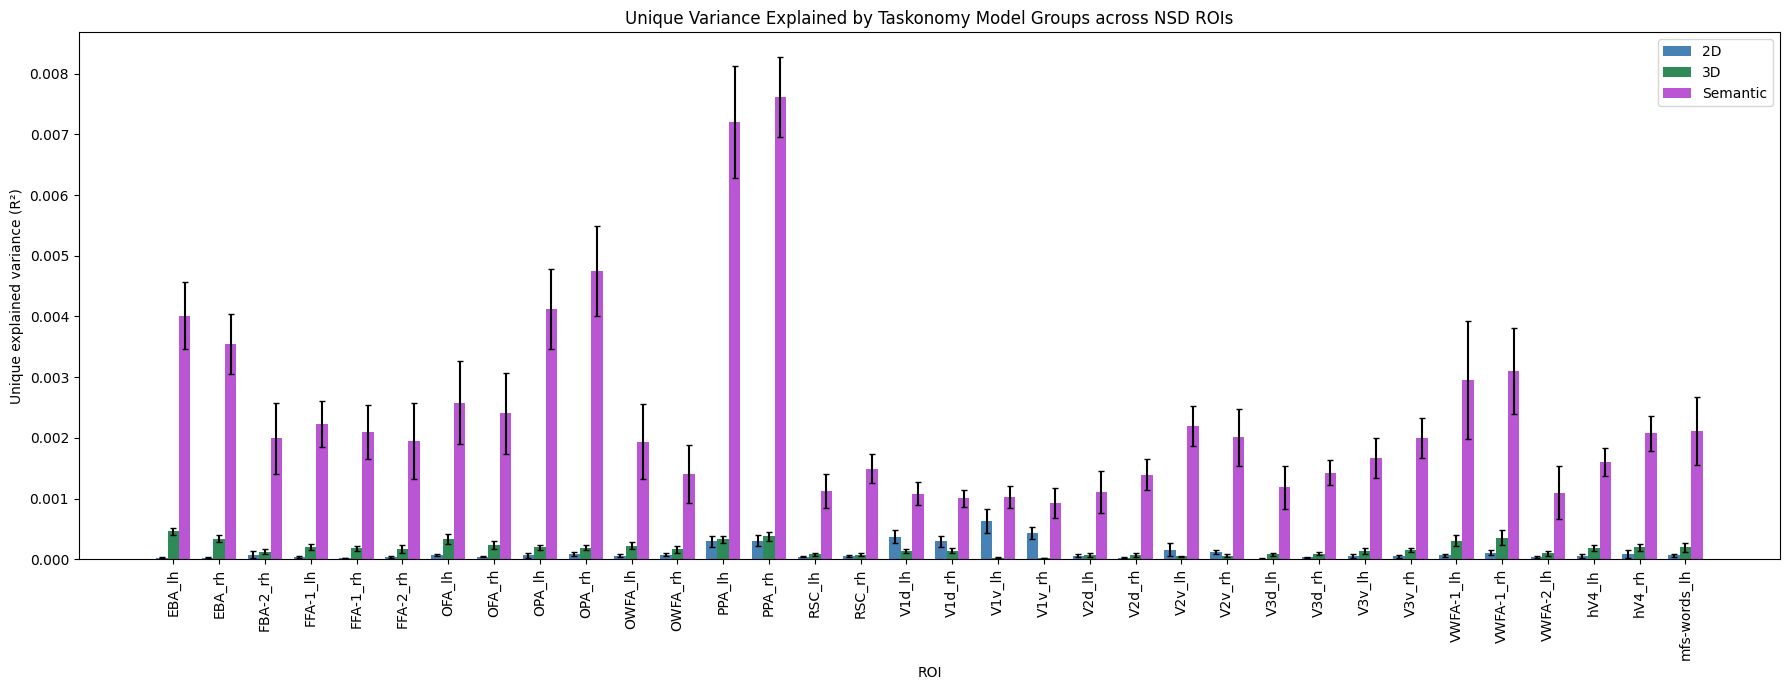

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Keep only ROIs available for all 8 subjects
plot_df = summary_df[
    summary_df["N_subjects"] == 8
].copy()

print("ROIs included in plot:", len(plot_df))

# Sort alphabetically for now
plot_df = plot_df.sort_values("ROI")

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(18, 7))

plt.bar(
    x - width,
    plot_df["Unique_2D_mean"],
    width,
    yerr=plot_df["Unique_2D_sem"],
    capsize=2,
    label="2D",
    color="steelblue"
)

plt.bar(
    x,
    plot_df["Unique_3D_mean"],
    width,
    yerr=plot_df["Unique_3D_sem"],
    capsize=2,
    label="3D",
    color="seagreen"
)

plt.bar(
    x + width,
    plot_df["Unique_Semantic_mean"],
    width,
    yerr=plot_df["Unique_Semantic_sem"],
    capsize=2,
    label="Semantic",
    color="mediumorchid"
)

plt.xticks(
    x,
    plot_df["ROI"],
    rotation=90
)

plt.ylabel("Unique explained variance (R²)")
plt.xlabel("ROI")

plt.title(
    "Unique Variance Explained by Taskonomy Model Groups across NSD ROIs"
)

plt.legend()
plt.tight_layout()

plt.show()

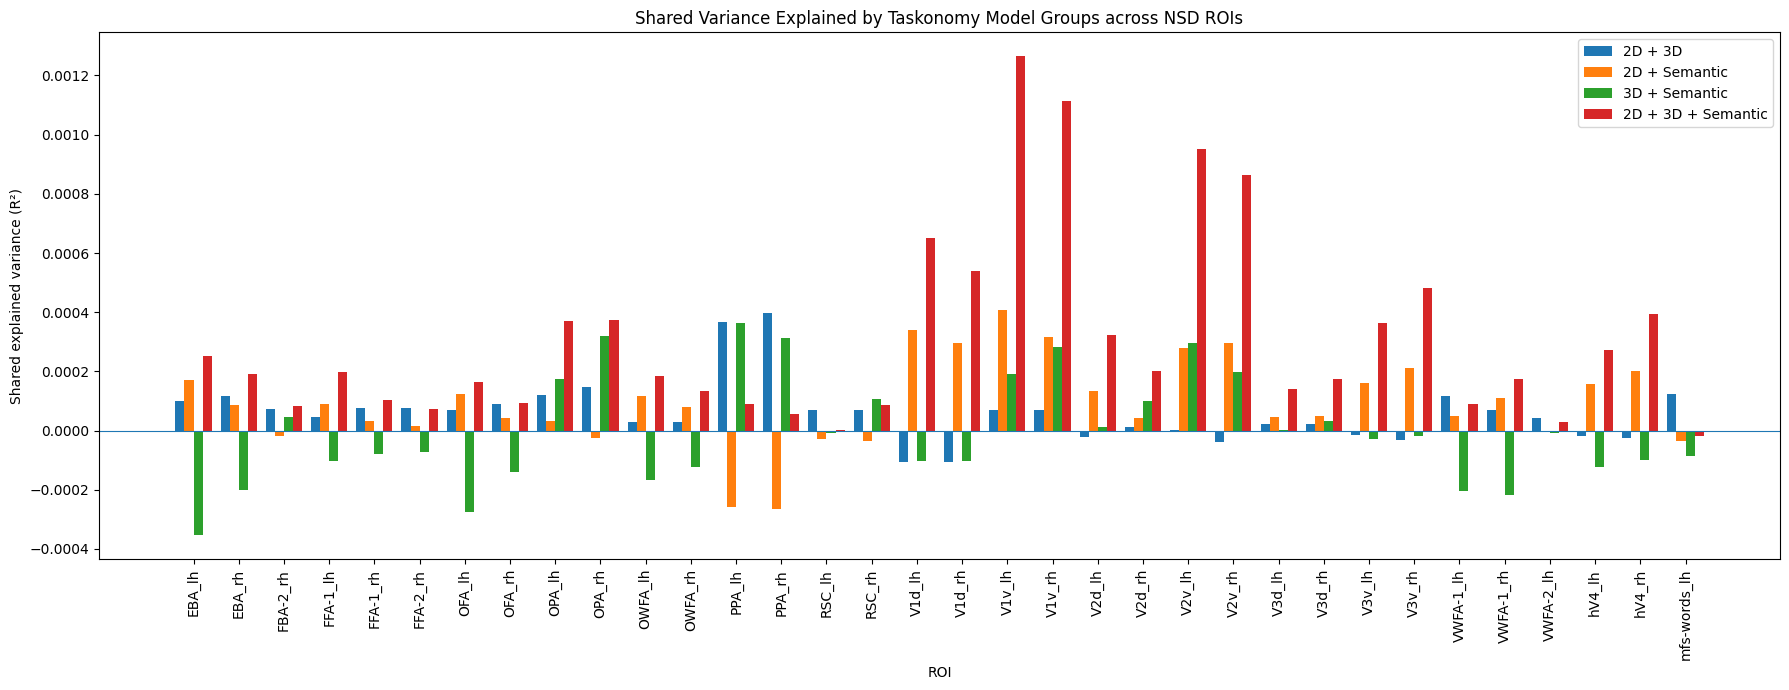

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

shared_plot_df = summary_df[
    summary_df["N_subjects"] == 8
].copy()

shared_plot_df = shared_plot_df.sort_values("ROI")

x = np.arange(len(shared_plot_df))
width = 0.20

plt.figure(figsize=(18, 7))

plt.bar(
    x - 1.5 * width,
    shared_plot_df["Shared_2D_3D_mean"],
    width,
    label="2D + 3D"
)

plt.bar(
    x - 0.5 * width,
    shared_plot_df["Shared_2D_Semantic_mean"],
    width,
    label="2D + Semantic"
)

plt.bar(
    x + 0.5 * width,
    shared_plot_df["Shared_3D_Semantic_mean"],
    width,
    label="3D + Semantic"
)

plt.bar(
    x + 1.5 * width,
    shared_plot_df["Shared_All_mean"],
    width,
    label="2D + 3D + Semantic"
)

plt.axhline(0, linewidth=0.8)

plt.xticks(
    x,
    shared_plot_df["ROI"],
    rotation=90
)

plt.ylabel("Shared explained variance (R²)")
plt.xlabel("ROI")

plt.title(
    "Shared Variance Explained by Taskonomy Model Groups across NSD ROIs"
)

plt.legend()
plt.tight_layout()

plt.show()